### Advanced Retrieval


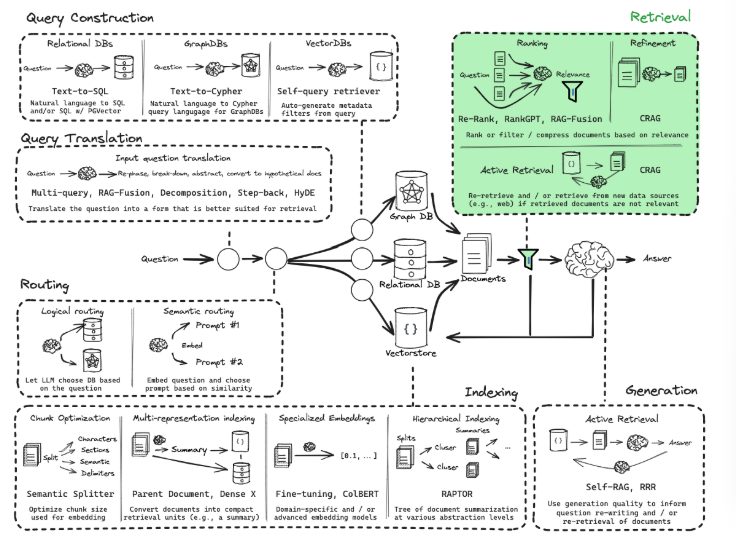

#### Re-ranking

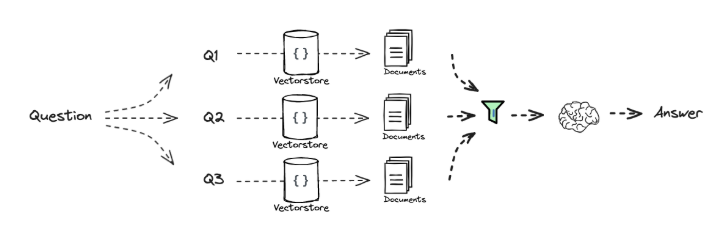

In [4]:
#### INDEXING ####
CHUNK_SIZE = 1000  # 文本分块大小
CHUNK_OVERLAP = 200  # 分块重叠长度
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型
LLM_MODEL = "qwen-turbo"  # 通义千问免费模型
TEMPERATURE = 0.0  # 生成温度（0=稳定输出）
# Load blog
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()

# Split
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separator="\n",  # 按换行符分割，更符合文本逻辑
    length_function=len  # 按字符数计算长度
)
splits = text_splitter.split_documents(blog_docs)
print(f"Total splits: {len(splits)}")
print(splits[0].page_content[:200])  # 打印第一个分块

# Make splits
splits = text_splitter.split_documents(blog_docs)

# Index
import os 
from langchain_community.chat_models.tongyi import ChatTongyi
from langchain_community.embeddings import HuggingFaceEmbeddings

DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY
llm = ChatTongyi(
    model=LLM_MODEL,
    temperature=TEMPERATURE,
    dashscope_api_key=DASHSCOPE_API_KEY
)
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)
from langchain_community.vectorstores import Chroma
vectorstore = Chroma.from_documents(documents=splits, 
                                    # embedding=CohereEmbeddings()
                                    embedding=embeddings)


retriever = vectorstore.as_retriever()

Created a chunk of size 2082, which is longer than the specified 1000
Created a chunk of size 1172, which is longer than the specified 1000
Created a chunk of size 2082, which is longer than the specified 1000
Created a chunk of size 1172, which is longer than the specified 1000


Total splits: 53
LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng
Building agents with LLM (large language model) as its core controller is a cool conce


In [5]:
from langchain_core.prompts import ChatPromptTemplate

# RAG-Fusion
template = """You are a helpful assistant that generates multiple search queries based on a single input query. \n
Generate multiple search queries related to: {question} \n
Output (4 queries):"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template)

In [6]:
from langchain_core.output_parsers import StrOutputParser

generate_queries = (
    prompt_rag_fusion 
    | llm
    | StrOutputParser() 
    | (lambda x: x.split("\n"))
)

In [ ]:
from langchain_core.load import dumps, loads

def reciprocal_rank_fusion(results: list[list], k=60):
    """ Reciprocal_rank_fusion that takes multiple lists of ranked documents 
        and an optional parameter k used in the RRF formula """
    
    # Initialize a dictionary to hold fused scores for each unique document
    fused_scores = {}

    # Iterate through each list of ranked documents
    for docs in results:
        # Iterate through each document in the list, with its rank (position in the list)
        for rank, doc in enumerate(docs):
            # Convert the document to a string format to use as a key (assumes documents can be serialized to JSON)
            doc_str = dumps(doc)
            # If the document is not yet in the fused_scores dictionary, add it with an initial score of 0
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            # Retrieve the current score of the document, if any
            previous_score = fused_scores[doc_str]
            # Update the score of the document using the RRF formula: 1 / (rank + k)
            fused_scores[doc_str] += 1 / (rank + k)

    # Sort the documents based on their fused scores in descending order to get the final reranked results
    reranked_results = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    # Return the reranked results as a list of tuples, each containing the document and its fused score
    return reranked_results

question = "What is task decomposition for LLM agents?"
retrieval_chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion
docs = retrieval_chain_rag_fusion.invoke({"question": question})
print(len(docs))

C:\Users\23017\AppData\Local\Temp\ipykernel_39524\1730588289.py:26: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  (loads(doc), score)


7

In [8]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough

# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)


final_rag_chain = (
    {"context": retrieval_chain_rag_fusion, 
     "question": itemgetter("question")} 
    | prompt
    | llm
    | StrOutputParser()
)

result = final_rag_chain.invoke({"question":question})
print(result)

Task decomposition for LLM agents refers to the process of breaking down complex tasks into smaller, manageable subgoals or steps. This approach helps the agent handle intricate problems more efficiently by enabling it to focus on individual components of a larger task. Techniques like Chain of Thought (CoT) and Tree of Thoughts (ToT) are commonly used for this purpose. CoT involves guiding the model to "think step by step," while ToT extends this by exploring multiple reasoning possibilities at each step, creating a tree structure for better problem-solving. Task decomposition can be achieved through simple prompting, task-specific instructions, or even with the assistance of external planners in certain cases.


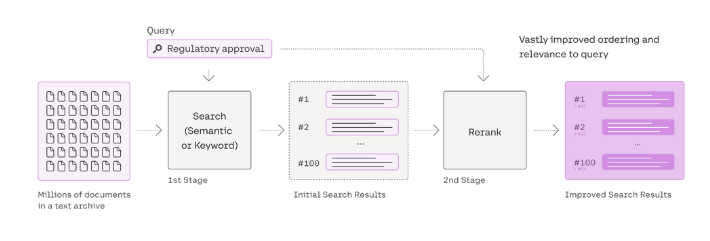

### We can also use Cohere Re-rank

In [ ]:
from langchain_community.llms import Cohere
from langchain_cohere import  CohereRerank
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

# Re-rank
compressor = CohereRerank()
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=retriever
)

compressed_docs = compression_retriever.get_relevant_documents(question)